Here is a getting started guide for data visualizations in Python.

The first cell imports the Grocery Store Data as long as it is saved in Current Directory/Data. So, when you download and save this file, make sure there is a 'Data' folder in the same place! 

In [ ]:
import pandas as pd
import os
from os.path import curdir
    
xl_path = os.path.join(curdir,'Data','MMA_860_Grocery_Data.csv')
df_xl = pd.read_csv(xl_path, header='infer', index_col='Obs')
df_xl.head()

,Grocery_Bill,N_Adults,Family_Income,Family_Size,N_Vehicles,Distance_to_Store,Vegetarian,N_Children,Family_Pet
Obs,,,,,,,,,
1,$357.73,2,"$142,141",4,3,15,0,2,1
2,$276.84,2,"$145,916",2,1,4,0,0,0
3,$197.92,1,"$86,185",1,2,14,0,0,0
4,$315.75,2,"$145,998",3,1,8,0,1,0
5,$202.89,1,"$79,341",1,2,19,1,0,0


The cell below shows you how to create a visualization with MatPlotLib (the best Python graphing tool!). 

First, we import matplotlib (line 1), and then we use the syntax plt.'chart_type' to create a chart! In this case, we use 'scatter' for a scatterplot, but there are many other options (hist for histogram, boxplot for a boxplot, etc.). See this link for all the options: https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html

You can also change the look of your chart. The 's' argument changes the shape and the 'c' argument changes the colour. Try adding this code chunk below right after ['Family_Income'] and see what happens:

,s=2,c='black'

In [6]:
def remove_dollar_sign(s):
    return s.replace("$","")
df_xl['Grocery_Bill'] = df_xl['Grocery_Bill'].map(
    remove_dollar_sign)
df_xl['Grocery_Bill'] = df_xl['Grocery_Bill'].astype(
    'float64')
def remove_comma(s):
    return s.replace(",","")
df_xl['Family_Income'] = df_xl['Family_Income'].map(
    remove_dollar_sign).map(remove_comma).astype('int64')

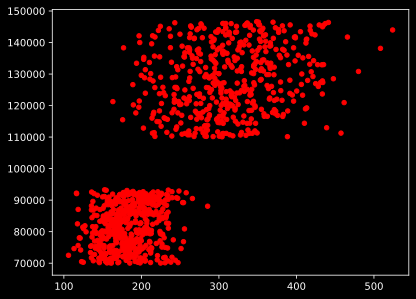

In [7]:

import matplotlib.pyplot as plt


plt.scatter(df_xl['Grocery_Bill'], df_xl['Family_Income'], s=20, c='red')

plt.show()



<Axes: title={'center': 'Family_Income'}, xlabel='N_Adults'>

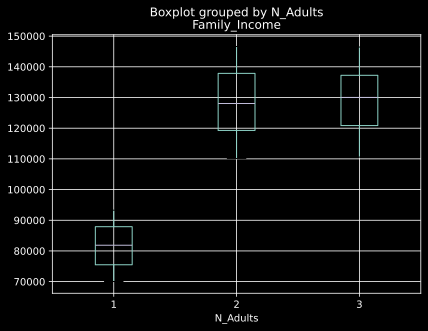

In [ ]:
df_xl.boxplot(column='Family_Income', by='N_Adults')

(array([174., 160., 183.,   4.,   0.,  71., 105.,  97., 103., 103.]),
 array([ 70037. ,  77694.4,  85351.8,  93009.2, 100666.6, 108324. ,
        115981.4, 123638.8, 131296.2, 138953.6, 146611. ]),
 <BarContainer object of 10 artists>)

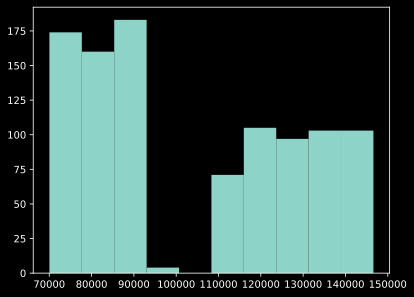

In [14]:
plt.hist(df_xl['Family_Income'], bins=10)

In [19]:
df_new = pd.DataFrame(df_xl.groupby('Family_Size')['Grocery_Bill'].sum())
df_new.head()

,Grocery_Bill
Family_Size,
1,81110.82
2,65584.33
3,32940.52
4,29450.41
5,33307.24


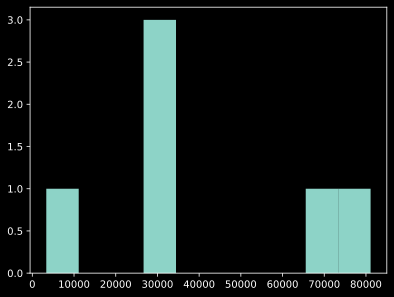

In [22]:
plt.hist(df_new,)
plt.show()

<Axes: xlabel='Family_Size'>

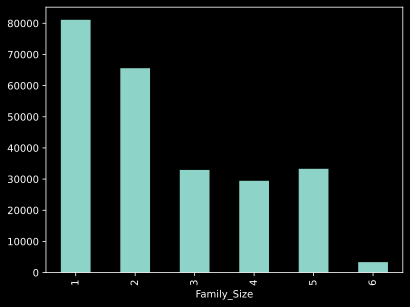

In [26]:
df_bar = df_xl.groupby('Family_Size', as_index=True)['Grocery_Bill'].sum()

df_bar.plot.bar()


In [27]:
df_xl.head()

,Grocery_Bill,N_Adults,Family_Income,Family_Size,N_Vehicles,Distance_to_Store,Vegetarian,N_Children,Family_Pet
Obs,,,,,,,,,
1,357.73,2,142141,4,3,15,0,2,1
2,276.84,2,145916,2,1,4,0,0,0
3,197.92,1,86185,1,2,14,0,0,0
4,315.75,2,145998,3,1,8,0,1,0
5,202.89,1,79341,1,2,19,1,0,0


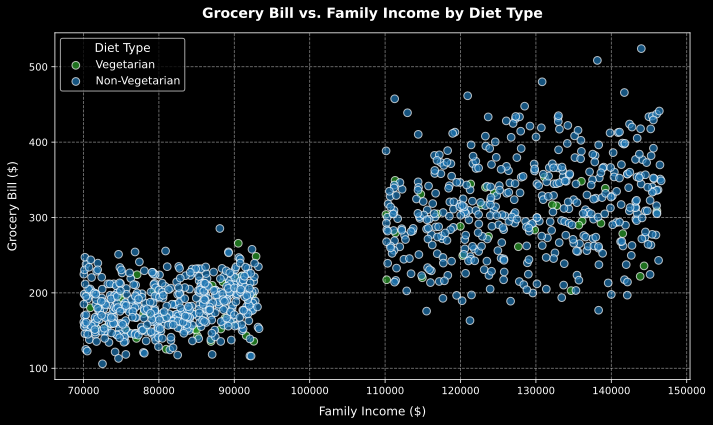

In [28]:
# 1. Create a clean canvas for the plot
plt.figure(figsize=(10, 6))

# 2. Filter the dataframe into two subsets
veg_data = df_xl[df_xl["Vegetarian"] == 1]
non_veg_data = df_xl[df_xl["Vegetarian"] == 0]

# 3. Plot the vegetarian points (Green)
plt.scatter(
    veg_data["Family_Income"],
    veg_data["Grocery_Bill"],
    color="#2ca02c",  # Green
    label="Vegetarian",
    alpha=0.7,  # Slight transparency for overlapping points
    edgecolors="w",  # White border around dots to separate them
    s=60,  # Size of the dots
)

# 4. Plot the non-vegetarian points (Blue)
plt.scatter(
    non_veg_data["Family_Income"],
    non_veg_data["Grocery_Bill"],
    color="#1f77b4",  # Blue
    label="Non-Vegetarian",
    alpha=0.7,
    edgecolors="w",
    s=60,
)

# 5. Add titles, labels, and formatting
plt.title(
    "Grocery Bill vs. Family Income by Diet Type",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Family Income ($)", fontsize=12, labelpad=10)
plt.ylabel("Grocery Bill ($)", fontsize=12, labelpad=10)

# 6. Enhance readability with a grid and legend
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(title="Diet Type", fontsize=11, title_fontsize=12)

# 7. Optimize layout and display the plot
plt.tight_layout()
plt.show()


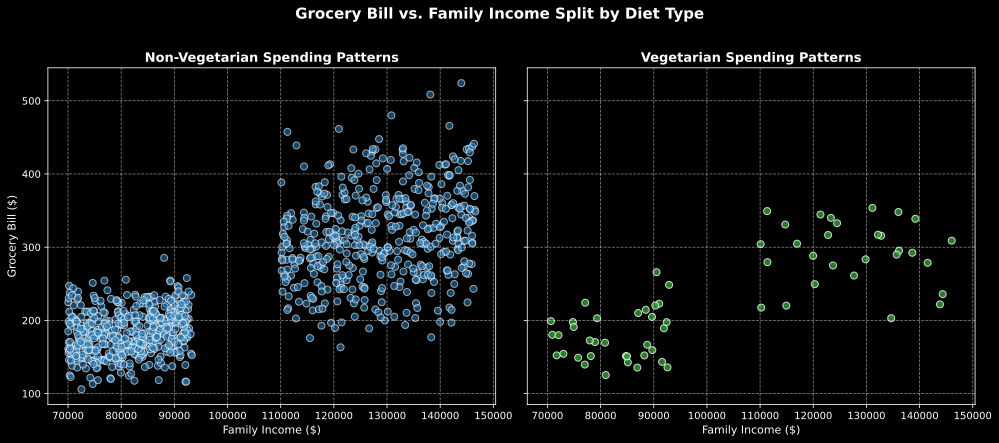

In [29]:
# 1. Create a figure with 1 row and 2 side-by-side subplots sharing the same Y-axis
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharey=True, sharex=True)

# 2. Filter the dataframe
veg_data = df_xl[df_xl["Vegetarian"] == 1]
non_veg_data = df_xl[df_xl["Vegetarian"] == 0]

# 3. Plot Non-Vegetarians on the FIRST subplot (Left side)
ax1.scatter(
    non_veg_data["Family_Income"],
    non_veg_data["Grocery_Bill"],
    color="#1f77b4",  # Blue
    alpha=0.6,
    edgecolors="w",
    s=50,
)
ax1.set_title("Non-Vegetarian Spending Patterns", fontsize=13, fontweight="bold")
ax1.set_xlabel("Family Income ($)", fontsize=11)
ax1.set_ylabel("Grocery Bill ($)", fontsize=11)
ax1.grid(True, linestyle="--", alpha=0.5)

# 4. Plot Vegetarians on the SECOND subplot (Right side)
ax2.scatter(
    veg_data["Family_Income"],
    veg_data["Grocery_Bill"],
    color="#2ca02c",  # Green
    alpha=0.8,  # Slightly higher opacity since there are fewer dots
    edgecolors="w",
    s=50,
)
ax2.set_title("Vegetarian Spending Patterns", fontsize=13, fontweight="bold")
ax2.set_xlabel("Family Income ($)", fontsize=11)
ax2.grid(True, linestyle="--", alpha=0.5)

# 5. Add a master title over both plots
plt.suptitle(
    "Grocery Bill vs. Family Income Split by Diet Type",
    fontsize=15,
    fontweight="bold",
    y=1.02,
)

# 6. Optimize spacing and display
plt.tight_layout()
plt.show()
